In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cvxopt as opt

import importlib

import markowitz_optimization
importlib.reload(markowitz_optimization)

<module 'markowitz_optimization' from 'c:\\Users\\User\\Desktop\\Github-local\\GFWM\\gfwm-app\\data_science\\quant\\markowitz_optimization.py'>

In [211]:
all_price_data = pd.read_csv("sp500_timeseries_13-24.csv")

entire_cov_matrix = pd.read_csv("sp500_adjusted_cov_matrix.csv")
entire_cov_matrix.set_index('ticker', inplace=True)

In [212]:
unique_tickers = pd.Series(all_price_data.columns[1:].values)

n=100
tickers = unique_tickers.sample(frac=(n+5)/500, random_state=19).reset_index(drop=True)

# keep selected tickers
price_data = all_price_data[tickers]

# keep entries where both tickers are present
cov_matrix = entire_cov_matrix.loc[tickers, tickers].to_numpy()

mean_log_returns = price_data.mean(axis = 0)
#print(mean_log_returns * 252)

mu_bar = np.mean(mean_log_returns)
mu_sd = np.std(mean_log_returns)

# Convert to cvxopt matrices
cov = opt.matrix(cov_matrix)
mean_returns = opt.matrix(mean_log_returns)

# risk free rate based of historical average of 30d yield
annual_risk_free_rate = 0.0153

# daily target returns. scale to annual for graphing
# start at daily risk free rate
target_returns = np.linspace(start=pow(annual_risk_free_rate+1, 1/365.0) - 1, stop=mu_bar + 1*mu_sd, num=80)

#TODO picking bounds: few different scenarios compared to equal weights

In [213]:
# generate portfolios
montecarlo_portfolios = markowitz_optimization.montecarlo_random_portfolios(mean_returns, 
                                                                            cov, 
                                                                            [0.0, 5.0/n], 
                                                                            iterations=1e5)

optimal_portfolios, best_fit = markowitz_optimization.calculate_optimal_portfolios(mean_returns, 
                                                                                   cov, 
                                                                                   target_returns, 
                                                                                   annual_risk_free_rate, 
                                                                                   bounds = [0.25/n, 4.0/n])

     pcost       dcost       gap    pres   dres
 0: -3.2392e-05 -3.8760e+00  2e+02  1e+01  7e-16
 1: -3.2383e-05 -3.6366e+00  1e+01  6e-01  3e-15
 2: -3.1861e-05 -1.8677e+00  4e+00  1e-01  3e-15
 3: -3.1151e-05 -3.4969e-01  2e+00  7e-02  2e-14
 4: -3.0389e-05  1.3039e+00  1e+00  5e-02  4e-14
 5: -3.0782e-05  8.4183e+00  2e+00  5e-02  1e-13
 6: -3.0919e-05  4.9631e+01  4e+00  5e-02  7e-13
 7: -3.0919e-05  2.1934e+02  1e+01  5e-02  3e-12
 8: -3.0942e-05  2.5352e+03  6e+01  5e-02  4e-11
 9: -3.0944e-05  8.9721e+04  4e+02  4e-02  1e-09
10: -3.0944e-05  2.0867e+07  3e+03  4e-02  3e-07
11: -3.0943e-05  1.4632e+11  5e+05  4e-02  1e-03
12: -3.0943e-05  6.3245e+12  2e+05  4e-02  4e-02
Terminated (singular KKT matrix).
     pcost       dcost       gap    pres   dres
 0: -4.1710e-05 -3.8743e+00  2e+02  1e+01  7e-16
 1: -4.1701e-05 -3.6375e+00  1e+01  6e-01  3e-15
 2: -4.1169e-05 -1.8609e+00  4e+00  1e-01  4e-15
 3: -4.0432e-05 -3.8970e-01  2e+00  6e-02  2e-14
 4: -3.9737e-05  1.0448e+00  1e+00  5

target_return                                                 0.000594
annual_return                                                 0.149609
annual_volatility                                             0.075149
weights              [0.0025098043219481023, 0.0025203916720604362,...
diversification                                               0.869342
Name: 59, dtype: object
99.90000000000002


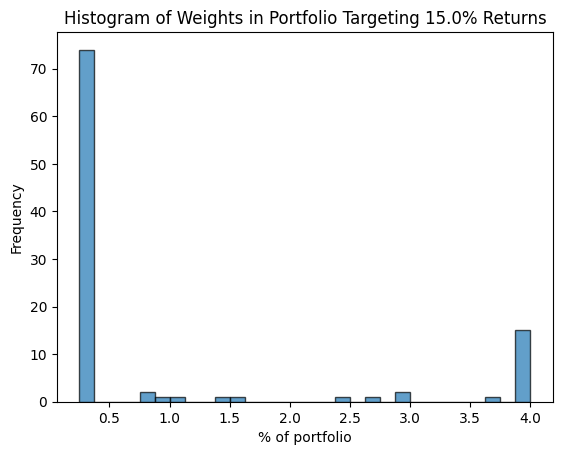

In [214]:
#find the portfolio nearest a given target return

optimal_portfolios.sort_values(by='annual_return', ascending= True)
target_return = 0.15
closest_portfolio = optimal_portfolios.loc[(optimal_portfolios['annual_return'] - target_return).abs().idxmin()]
closest_portfolio_weights = closest_portfolio['weights'] * 100

print(closest_portfolio)

print(sum(closest_portfolio_weights))

plt.hist(closest_portfolio_weights, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('% of portfolio')
plt.ylabel('Frequency')
plt.title(f'Histogram of Weights in Portfolio Targeting {target_return * 100}% Returns')
plt.show()

In [235]:
#calculate tangent line to best fit curve, passing through (0, annual_rfr)
# vol = ar^2 + br + c
# derivative: 2ar + b

# point slope form of line also passing through (vol_t, ret_t)
# vol - vol_t = slope * (ret - ret_t)

# at the tangency point (vol_t, ret_t), slopes are equal:
# vol_t / (ret_t - rfr) = 2a * ret_t + b
# solve for ret_t to find the tangency point (ret_t, vol_t)

# best_fit(ret_t) / (ret_t - rfr) = 2a * ret_t + b
# ar^2 + br + c = (r-rfr)(2ar+b)
#               = 2a r^2 + (b-2arfr) * r - rfr*b
# 0 = ar^2 - 2arfr * r - c - rfr*b

[c, b, a] = best_fit.convert().coef
tangency_poly = np.polynomial.Polynomial([-c - b * annual_risk_free_rate, 
                                          -2*a* annual_risk_free_rate,
                                          a])
#find root in the acceptable range
ret_t = [root for root in tangency_poly.roots() if 0 <= root <= 0.5][0]
print(ret_t)
vol_t = best_fit(ret_t)

slope = vol_t / (ret_t - annual_risk_free_rate)

def tangent_line(r):
    return vol_t + (slope * (r-ret_t))

3.5390652388019617 -0.7975187560187494 0.11441830143427614
0.18593518846429316
0.0


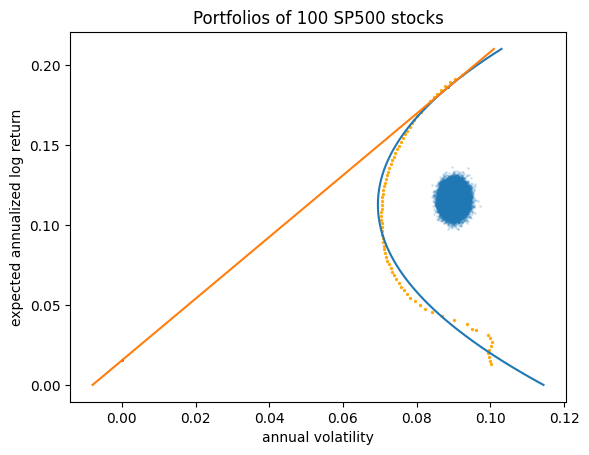

In [236]:
fig = plt.figure()

plt.scatter(montecarlo_portfolios['annual_volatility'],
            montecarlo_portfolios['annual_return'], s=1, alpha=0.15)

plt.scatter(optimal_portfolios['annual_volatility'],
            optimal_portfolios['annual_return'], s=2, c='orange', alpha=0.9)

plt.scatter(0, annual_risk_free_rate, s= 1, color='red')
plt.scatter(vol_t, ret_t, s= 1, color='green')

plt.ylabel('expected annualized log return')
plt.xlabel('annual volatility')

x = np.linspace(start=0.0, stop = 0.21, num = 100)

plt.plot([best_fit(xi) for xi in x], x)

plt.plot([tangent_line(xi) for xi in x], x)

plt.title(f"Portfolios of {n} SP500 stocks")
plt.show()

In [255]:
# given that optimal_portfolios is already sorted by return, find the row closest to ret_t
ideal_portfolio = optimal_portfolios.loc[(optimal_portfolios['annual_return'] - ret_t).abs().idxmin()][['annual_return', 'annual_volatility', 'weights']]

ideal_portfolio_df = pd.DataFrame({
    'annual_return': [ideal_portfolio['annual_return']] + [None] * (n - 1),
    'annual_volatility': [ideal_portfolio['annual_volatility']] + [None] * (n - 1),
    'weights': ideal_portfolio['weights']
})

print(ideal_portfolio_df)

ideal_portfolio_df.to_csv("ideal_portfolio.csv", index=False)

         ret       vol   weights
0   0.186709  0.087736  0.002506
1        NaN       NaN  0.002520
2        NaN       NaN  0.039991
3        NaN       NaN  0.039990
4        NaN       NaN  0.002511
..       ...       ...       ...
95       NaN       NaN  0.002536
96       NaN       NaN  0.002535
97       NaN       NaN  0.002840
98       NaN       NaN  0.002502
99       NaN       NaN  0.002705

[100 rows x 3 columns]


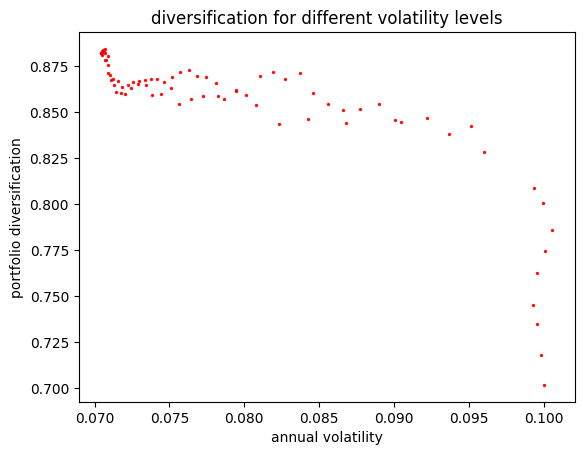

In [238]:
plt.scatter(optimal_portfolios['annual_volatility'],
            optimal_portfolios['diversification'], s=2, c='red', alpha=0.9)
plt.xlabel('annual volatility')
plt.ylabel('portfolio diversification')
plt.title('diversification for different volatility levels')
plt.show()